<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: Complemento**

## **1. Text mining**

In [ ]:
!pip -q install pdfplumber nltk wordcloud spacy scikit-learn
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 60.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 67.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import requests
url = "https://cdn.www.gob.pe/uploads/document/file/4046338/MENSAJE%20A%20LA%20NACI%C3%93N%20DE%20LA%20PRESIDENTA%20DE%20LA%20REP%C3%9ABLICA%20DINA%20BOLUARTE%20%2013.01.2023%20%281%29.pdf.pdf"
pdf = requests.get(url)
with open("mensaje.pdf","wb") as f:
    f.write(pdf.content)

In [ ]:
import pdfplumber
texto=""
with pdfplumber.open("mensaje.pdf") as pdf:
    for pagina in pdf.pages:
        texto += pagina.extract_text()
print(texto[:2000])

MENSAJE A LA NACIÓN
DE LA PRESIDENTA DE LA REPÚBLICA,
SEÑORA DINA ERCILIA BOLUARTE ZEGARRA
13 DE ENERO DE 2023
Hermanas y hermanos de todo el país:
Cuando asumí el Gobierno de transición, en cumplimiento del mandato
constitucional y un firme compromiso con la patria, jamás pensé que esta sería una
tarea fácil ni sencilla.
Desde el primer día, fui consciente que asumía esta responsabilidad en medio de
una grave crisis política y social, resultado de años de confrontación y décadas de
olvido y postergación de las justas demandas del pueblo.
Recibimos un país polarizado, un país enfrentado, un país donde existen sectores
extremistas que buscan generar el desorden y el caos, con claros intereses
subalternos: destruir la institucionalidad y la democracia y pretender ganar a río
revuelto.
Recibimos también un país con promesas que no se cumplieron. No solo me refiero
a las promesas que se hicieron elección tras elección, gobierno tras gobierno; sino
también a aquellas que se ofrecieron duran

In [ ]:
import re
texto = texto.lower()
texto = re.sub(r'\n',' ',texto)
texto = re.sub(r'\d+',' ',texto)
texto = re.sub(r'[^\w\s]',' ',texto)
texto = re.sub(r'\s+',' ',texto)

In [ ]:
# Tokenización
from nltk.tokenize import word_tokenize
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
tokens = word_tokenize(texto,language="spanish")
tokens[:30]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['mensaje',
 'a',
 'la',
 'nación',
 'de',
 'la',
 'presidenta',
 'de',
 'la',
 'república',
 'señora',
 'dina',
 'ercilia',
 'boluarte',
 'zegarra',
 'de',
 'enero',
 'de',
 'hermanas',
 'y',
 'hermanos',
 'de',
 'todo',
 'el',
 'país',
 'cuando',
 'asumí',
 'el',
 'gobierno',
 'de']

In [ ]:
# Stopwords
from nltk.corpus import stopwords
nltk.download("stopwords")
stop = stopwords.words("spanish")
tokens = [w for w in tokens if w not in stop]
tokens[:30]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['mensaje',
 'nación',
 'presidenta',
 'república',
 'señora',
 'dina',
 'ercilia',
 'boluarte',
 'zegarra',
 'enero',
 'hermanas',
 'hermanos',
 'país',
 'asumí',
 'gobierno',
 'transición',
 'cumplimiento',
 'mandato',
 'constitucional',
 'firme',
 'compromiso',
 'patria',
 'jamás',
 'pensé',
 'tarea',
 'fácil',
 'sencilla',
 'primer',
 'día',
 'consciente']

In [ ]:
# Lematización
import spacy
nlp = spacy.load("es_core_news_sm")
doc = nlp(" ".join(tokens))
lemas = [token.lemma_ for token in doc]
lemas[:40]

['mensaje',
 'nación',
 'presidenta',
 'república',
 'señora',
 'dina',
 'ercilia',
 'boluarte',
 'zegarra',
 'enero',
 'hermana',
 'hermano',
 'país',
 'asumí',
 'gobierno',
 'transición',
 'cumplimiento',
 'mandato',
 'constitucional',
 'firme',
 'compromiso',
 'patria',
 'jamás',
 'pensar',
 'tarea',
 'fácil',
 'sencillo',
 'primero',
 'día',
 'consciente',
 'asumía',
 'responsabilidad',
 'medio',
 'grave',
 'crisis',
 'político',
 'social',
 'resultado',
 'año',
 'confrontación']

In [ ]:
from collections import Counter
freq = Counter(lemas)
freq.most_common(20)

[('país', 19),
 ('poder', 18),
 ('peruano', 18),
 ('pueblo', 16),
 ('hermano', 10),
 ('gobierno', 10),
 ('decir', 10),
 ('hacer', 9),
 ('pedir', 9),
 ('trabajar', 8),
 ('diálogo', 8),
 ('derecho', 7),
 ('manera', 7),
 ('ser', 7),
 ('querer', 7),
 ('hermana', 6),
 ('social', 6),
 ('tiempo', 6),
 ('paz', 6),
 ('político', 5)]

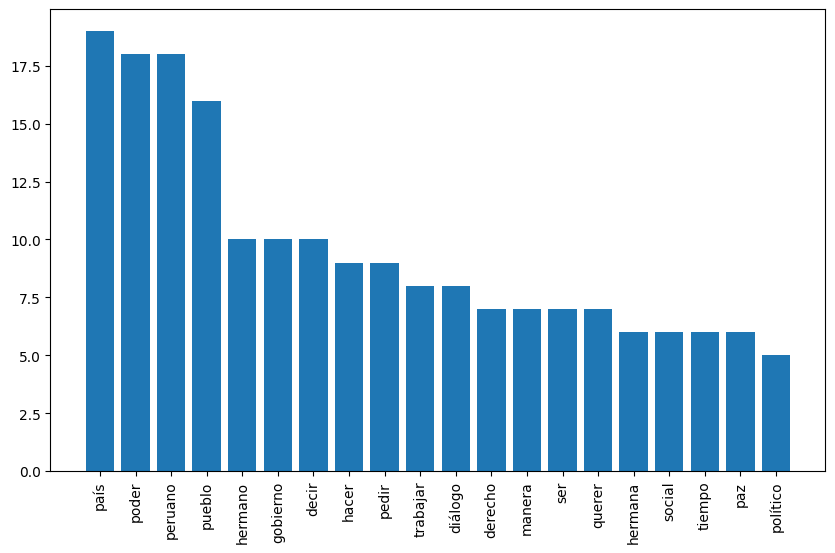

In [ ]:
import matplotlib.pyplot as plt
palabras = dict(freq.most_common(20))
plt.figure(figsize=(10,6))
plt.bar(palabras.keys(),palabras.values())
plt.xticks(rotation=90)
plt.show()

## **2. Web scapping**

In [ ]:
!pip install osmnx
import osmnx as ox

restaurantes = ox.features_from_place(
    "Huancayo, Peru",
    tags={"amenity":"restaurant"}
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.9 MB/s eta 0:00:00


In [ ]:
restaurantes

geometry  \
element id                                                              
node    3458069831                        POINT (-75.20928 -12.06762)   
        4143759570                        POINT (-75.28478 -11.95127)   
        4150231061                         POINT (-75.2169 -12.05841)   
        4150231328                        POINT (-75.20534 -12.06648)   
        4314839489                        POINT (-75.20363 -12.04662)   
...                                                               ...   
way     972107750   POLYGON ((-75.21024 -12.06663, -75.21018 -12.0...   
        972107760   POLYGON ((-75.20894 -12.06679, -75.20877 -12.0...   
        972107761   POLYGON ((-75.20926 -12.06685, -75.2092 -12.06...   
        986934106   POLYGON ((-75.21038 -12.0664, -75.21031 -12.06...   
        1324561871  POLYGON ((-75.19932 -12.07267, -75.19925 -12.0...   

                       amenity   cuisine                   name  \
element id                                                        
node    3458069831  restaurant  peruvian  Detrás de la catedral   
        4143759570  restaurant  regional              Todo Rico   
        4150231061  restaurant       NaN             SuperPollo   
        4150231328  restaurant     pizza              Pizza Hut   
        4314839489  restaurant       NaN        Hacienda Vargas   
...                        ...       ...                    ...   
way     972107750   restaurant  american             Mamá Meche   
        972107760   restaurant       NaN           El Encuentro   
        972107761   restaurant       NaN             Paris Café   
        986934106   restaurant       NaN                    NaN   
        1324561871  restaurant  peruvian     Restuarant Eriksen   

                   addr:housenumber addr:postcode            addr:street  \
element id                                                                 
node    3458069831             3354         12001           Jirón Ancash   
        4143759570              NaN           NaN  Carretera Central Sur   
        4150231061              NaN           NaN                    NaN   
        4150231328              NaN           NaN                    NaN   
        4314839489              NaN           NaN           Las Begonias   
...                             ...           ...                    ...   
way     972107750               NaN           NaN                    NaN   
        972107760               NaN           NaN                    NaN   
        972107761               NaN           NaN                    NaN   
        986934106               NaN           NaN                    NaN   
        1324561871              NaN           NaN                    NaN   

                   description email internet_access  ... name:en  \
element id                                            ...           
node    3458069831         NaN   NaN             NaN  ...     NaN   
        4143759570         NaN   NaN             NaN  ...     NaN   
        4150231061         NaN   NaN             NaN  ...     NaN   
        4150231328         NaN   NaN             NaN  ...     NaN   
        4314839489         NaN   NaN             NaN  ...     NaN   
...                        ...   ...             ...  ...     ...   
way     972107750          NaN   NaN             NaN  ...     NaN   
        972107760          NaN   NaN             NaN  ...     NaN   
        972107761          NaN   NaN             NaN  ...     NaN   
        986934106          NaN   NaN             NaN  ...     NaN   
        1324561871         NaN   NaN             NaN  ...     NaN   

                   addr:country denomination  ele office religion  \
element id                                                          
node    3458069831          NaN          NaN  NaN    NaN      NaN   
        4143759570          NaN          NaN  NaN    NaN      NaN   
        4150231061          NaN          NaN  NaN    NaN      NaN   
       

**Transfermarket:**

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
url = "https://www.transfermarkt.com/peru/kader/verein/3584"

In [ ]:
headers = {"User-Agent": "Mozilla/5.0"}
respuesta = requests.get(url, headers=headers)
print(respuesta.status_code)

200


In [ ]:
soup = BeautifulSoup(respuesta.text, "html.parser")

In [ ]:
tabla = soup.find("table", class_="items")

In [ ]:
filas = tabla.find_all("tr")

In [ ]:
datos = []
for fila in filas:
    columnas = fila.find_all("td")
    if len(columnas) >= 8:
        jugador = columnas[3].get_text(strip=True)
        posicion = columnas[4].get_text(strip=True)
        edad = columnas[5].get_text(strip=True)
        valor = columnas[7].get_text(strip=True)
        datos.append([jugador, posicion, edad, valor])

In [ ]:
df = pd.DataFrame(datos, columns=[ "Jugador", "Posición", "Edad", "Valor de mercado"])

In [ ]:
df

,Jugador,Posición,Edad,Valor de mercado
0,Pedro Gallese,Goalkeeper,36,€350k
1,Matías Córdova,Goalkeeper,24,€350k
2,Alejandro Duarte,Goalkeeper,32,€325k
3,Fabio Gruber,Centre-Back,23,€3.00m
4,Renzo Garcés,Centre-Back,30,€1.30m
5,Matías Lazo,Centre-Back,22,€1.20m
6,Marcos López,Left-Back,26,€4.00m
7,Oliver Sonne,Right-Back,25,€4.00m
8,Marco Huamán,Right-Back,23,€600k
9,Erick Noriega,Defensive Midfield,24,€5.00m
